In [1]:
import os
print(os.listdir())

['.config', 'archive (4).zip', 'sample_data']


In [2]:
import zipfile

with zipfile.ZipFile('archive (4).zip', 'r') as zip_ref:
    zip_ref.extractall()

print("Extracted successfully")

Extracted successfully


In [3]:
import os

print(os.listdir())

['.config', 'movie_genre_classification_final.csv', 'archive (4).zip', 'sample_data']


In [4]:
import os

print(os.listdir())

['.config', 'movie_genre_classification_final.csv', 'archive (4).zip', 'sample_data']


In [5]:
import pandas as pd

df = pd.read_csv("movie_genre_classification_final.csv")

df.head()

,Title,Year,Director,Duration,Rating,Votes,Description,Language,Country,Budget_USD,BoxOffice_USD,Genre,Production_Company,Content_Rating,Lead_Actor,Num_Awards,Critic_Reviews
0,Winds of Fate 4,1980,R. Lee,167,4.1,182425,A touching love story with heartwarming moments.,Spanish,China,39979615,179936008,Romance,DreamWorks,R,Kangana Ranaut,8,229
1,Firestorm 11,2014,S. Chen,166,4.1,449351,A fast-paced thriller with intense action scenes.,Korean,China,116404774,802121619,Action,Netflix,R,Kangana Ranaut,20,466
2,Silent Echo 2,2016,A. Khan,170,4.1,363328,A fast-paced thriller with intense action scenes.,Korean,Japan,166261330,225526871,Action,Pixar,PG,Amitabh Bachchan,16,539
3,City Lights 4,1982,L. Zhang,170,9.9,62371,An emotional journey exploring complex charact...,Japanese,Japan,28861315,69813738,Drama,Netflix,NC-17,Natalie Portman,15,606
4,Broken Truth 1,1990,L. Zhang,91,5.3,4600,An imaginative world filled with magic and won...,Korean,USA,43890403,375136716,Fantasy,Studio Ghibli,PG,Chris Evans,6,330


In [6]:
df.columns

Index(['Title', 'Year', 'Director', 'Duration', 'Rating', 'Votes',
       'Description', 'Language', 'Country', 'Budget_USD', 'BoxOffice_USD',
       'Genre', 'Production_Company', 'Content_Rating', 'Lead_Actor',
       'Num_Awards', 'Critic_Reviews'],
      dtype='object')

In [9]:
df.columns.tolist()

['Title',
 'Year',
 'Director',
 'Duration',
 'Rating',
 'Votes',
 'Description',
 'Language',
 'Country',
 'Budget_USD',
 'BoxOffice_USD',
 'Genre',
 'Production_Company',
 'Content_Rating',
 'Lead_Actor',
 'Num_Awards',
 'Critic_Reviews']

In [10]:
df = df[['Description', 'Genre']]

df.head()

,Description,Genre
0,A touching love story with heartwarming moments.,Romance
1,A fast-paced thriller with intense action scenes.,Action
2,A fast-paced thriller with intense action scenes.,Action
3,An emotional journey exploring complex charact...,Drama
4,An imaginative world filled with magic and won...,Fantasy


In [11]:
df.isnull().sum()

,0
Description,0
Genre,0


In [12]:
df.dropna(inplace=True)
df.shape

/tmp/ipykernel_3663/2053667463.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


(50000, 2)

In [13]:
X = df['Description']
y = df['Genre']

print(X.shape)
print(y.shape)

(50000,)
(50000,)


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(X)

print(X.shape)

(50000, 36)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(40000, 36)
(10000, 36)


In [16]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [17]:
y_pred = model.predict(X_test)

print("Prediction completed")

Prediction completed


In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Action       1.00      1.00      1.00      1399
      Comedy       1.00      1.00      1.00      1447
       Drama       1.00      1.00      1.00      1448
     Fantasy       1.00      1.00      1.00      1430
      Horror       1.00      1.00      1.00      1485
     Romance       1.00      1.00      1.00      1429
    Thriller       1.00      1.00      1.00      1362

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



[[1399    0    0    0    0    0    0]
 [   0 1447    0    0    0    0    0]
 [   0    0 1448    0    0    0    0]
 [   0    0    0 1430    0    0    0]
 [   0    0    0    0 1485    0    0]
 [   0    0    0    0    0 1429    0]
 [   0    0    0    0    0    0 1362]]


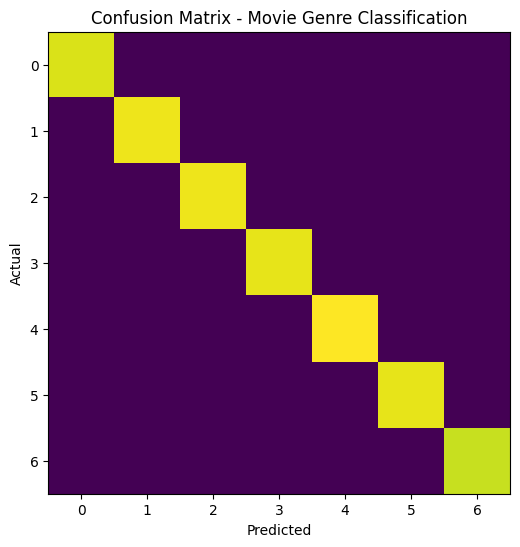

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix - Movie Genre Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()